# ResNet-50 Final Results

This notebook presents the final selected ResNet-50 model results for real-vs-fake face classification.

**Notebook purpose:** This final-results notebook summarizes the selected model configuration and saved evaluation results. It is designed for a GitHub repo and does **not** retrain the model. Full training/tuning code is kept in `ResNet50_experiments.ipynb`. A cleaner runnable evaluation/tuning template is kept in `ResNet50_Reproducibility.ipynb`.

## How to use this notebook

Run this notebook after cloning the repository. The result values are embedded from the completed experiment notebook so the final report can be viewed immediately. If matching CSV files are later added to a `results/` folder, you can replace the embedded values with loaded files without changing the structure.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == 'notebooks' else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / 'results'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'

print('Project root:', PROJECT_ROOT)
print('Results directory:', RESULTS_DIR)
print('Checkpoints directory:', CHECKPOINTS_DIR)

Project root: /
Results directory: /results
Checkpoints directory: /checkpoints


## Final selected configuration

In [2]:
final_config = [{
    'Model': 'ResNet-50',
    'Selected Run': 'R13',
    'Checkpoint': 'R13_best.pth',
    'Optimizer': 'AdamW',
    'Learning Rate': 1e-4,
    'Weight Decay': 1e-3,
    'Augmentation': 'light',
    'Batch Size': 8,
    'Scheduler': 'ReduceLROnPlateau',
    'Epochs': 10,
    'Patience': 3,
    'Best Epoch': 10,
    'Best Val Loss': 0.05975774798369208,
    'Best Val Accuracy': 0.9790,
    'Best Val F1': 0.9790251697962445,
    'Best Val ROC-AUC': 0.9980216849999999,
}]
final_config_df = pd.DataFrame(final_config)
final_config_df

,Model,Selected Run,Checkpoint,Optimizer,Learning Rate,Weight Decay,Augmentation,Batch Size,Scheduler,Epochs,Patience,Best Epoch,Best Val Loss,Best Val Accuracy,Best Val F1,Best Val ROC-AUC
0,ResNet-50,R13,R13_best.pth,AdamW,0.0001,0.001,light,8,ReduceLROnPlateau,10,3,10,0.059758,0.979,0.979025,0.998022


## Tuning summary

The table below summarizes the main tuning stages that led to the final selected run.

In [3]:
tuning_data = [
    {'Tuning Stage': 'Learning Rate', 'Selected Run': 'R02', 'Compared Setting': 'learning_rate', 'Chosen Value': '1e-4', 'Val Loss': 0.083167, 'Val Accuracy': 0.9690, 'Val F1': 0.969124, 'Val ROC-AUC': 0.995518, 'Best Epoch': 10},
    {'Tuning Stage': 'Optimizer', 'Selected Run': 'R04', 'Compared Setting': 'optimizer', 'Chosen Value': 'AdamW', 'Val Loss': 0.082343, 'Val Accuracy': 0.97110, 'Val F1': 0.970966, 'Val ROC-AUC': 0.996259, 'Best Epoch': 10},
    {'Tuning Stage': 'Weight Decay', 'Selected Run': 'R08', 'Compared Setting': 'weight_decay', 'Chosen Value': '1e-3', 'Val Loss': 0.074883, 'Val Accuracy': 0.97430, 'Val F1': 0.974514, 'Val ROC-AUC': 0.996844, 'Best Epoch': 10},
    {'Tuning Stage': 'Augmentation', 'Selected Run': 'R08', 'Compared Setting': 'augmentation', 'Chosen Value': 'light', 'Val Loss': 0.074883, 'Val Accuracy': 0.97430, 'Val F1': 0.974514, 'Val ROC-AUC': 0.996844, 'Best Epoch': 10},
    {'Tuning Stage': 'Batch Size', 'Selected Run': 'R08', 'Compared Setting': 'batch_size', 'Chosen Value': '8', 'Val Loss': 0.074883, 'Val Accuracy': 0.97430, 'Val F1': 0.974514, 'Val ROC-AUC': 0.996844, 'Best Epoch': 10},
    {'Tuning Stage': 'Scheduler', 'Selected Run': 'R13', 'Compared Setting': 'scheduler', 'Chosen Value': 'ReduceLROnPlateau', 'Val Loss': 0.059758, 'Val Accuracy': 0.97900, 'Val F1': 0.979025, 'Val ROC-AUC': 0.998022, 'Best Epoch': 10},
]
tuning_df = pd.DataFrame(tuning_data)
tuning_df

,Tuning Stage,Selected Run,Compared Setting,Chosen Value,Val Loss,Val Accuracy,Val F1,Val ROC-AUC,Best Epoch
0,Learning Rate,R02,learning_rate,1e-4,0.083167,0.9690,0.969124,0.995518,10
1,Optimizer,R04,optimizer,AdamW,0.082343,0.9711,0.970966,0.996259,10
2,Weight Decay,R08,weight_decay,1e-3,0.074883,0.9743,0.974514,0.996844,10
3,Augmentation,R08,augmentation,light,0.074883,0.9743,0.974514,0.996844,10
4,Batch Size,R08,batch_size,8,0.074883,0.9743,0.974514,0.996844,10
5,Scheduler,R13,scheduler,ReduceLROnPlateau,0.059758,0.9790,0.979025,0.998022,10


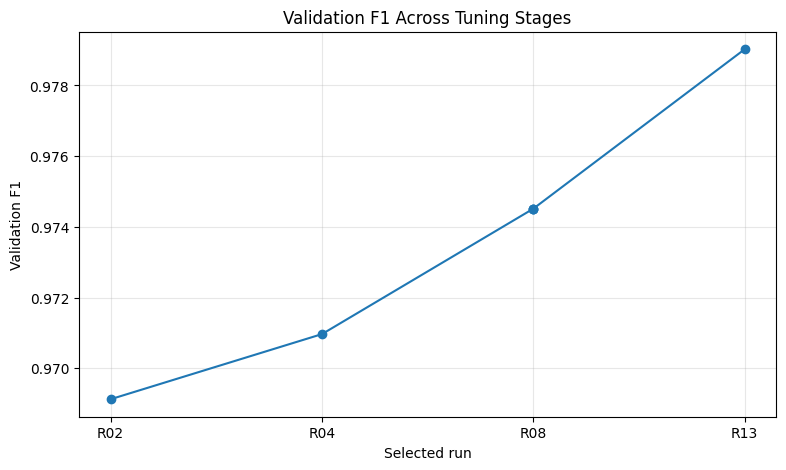

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(tuning_df['Selected Run'] if 'Selected Run' in tuning_df.columns else tuning_df['Run ID'], tuning_df['Val F1'], marker='o')
plt.xlabel('Selected run')
plt.ylabel('Validation F1')
plt.title('Validation F1 Across Tuning Stages')
plt.grid(True, alpha=0.3)
plt.show()

## Final evaluation results

These are the saved evaluation metrics from the final selected checkpoint on the held-out test split and two external unseen datasets.

In [5]:
evaluation_data = [
    {'Evaluation Set': 'Held-out Test Split', 'Dataset': 'Kaggle 140K test split', 'Checkpoint': 'R13_best.pth', 'Accuracy': 0.978600, 'Precision': 0.977931, 'Recall': 0.979300, 'F1': 0.978615, 'ROC-AUC': 0.997985, 'Loss': 0.060163},
    {'Evaluation Set': 'Unseen Dataset A', 'Dataset': '130K Real vs Fake Face', 'Checkpoint': 'R13_best.pth', 'Accuracy': 0.519454, 'Precision': 0.521867, 'Recall': 0.991114, 'F1': 0.683722, 'ROC-AUC': 0.573175, 'Loss': 4.704170},
    {'Evaluation Set': 'Unseen Dataset B', 'Dataset': 'Deepfake vs Real Eval', 'Checkpoint': 'R13_best.pth', 'Accuracy': 0.493000, 'Precision': 0.496475, 'Recall': 0.986000, 'F1': 0.660415, 'ROC-AUC': 0.618770, 'Loss': 4.827572},
]
evaluation_df = pd.DataFrame(evaluation_data)
evaluation_df

,Evaluation Set,Dataset,Checkpoint,Accuracy,Precision,Recall,F1,ROC-AUC,Loss
0,Held-out Test Split,Kaggle 140K test split,R13_best.pth,0.978600,0.977931,0.979300,0.978615,0.997985,0.060163
1,Unseen Dataset A,130K Real vs Fake Face,R13_best.pth,0.519454,0.521867,0.991114,0.683722,0.573175,4.704170
2,Unseen Dataset B,Deepfake vs Real Eval,R13_best.pth,0.493000,0.496475,0.986000,0.660415,0.618770,4.827572


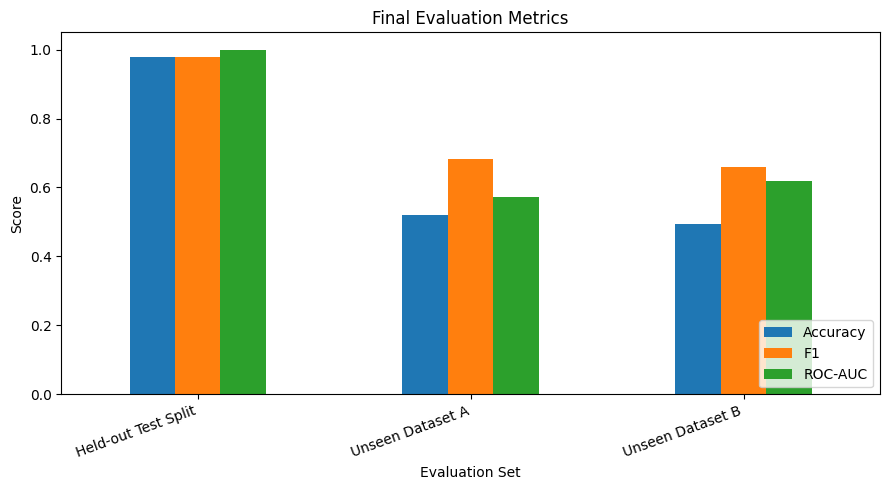

In [6]:
metrics = ['Accuracy', 'F1', 'ROC-AUC']
ax = evaluation_df.set_index('Evaluation Set')[metrics].plot(kind='bar', figsize=(9, 5))
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('Final Evaluation Metrics')
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

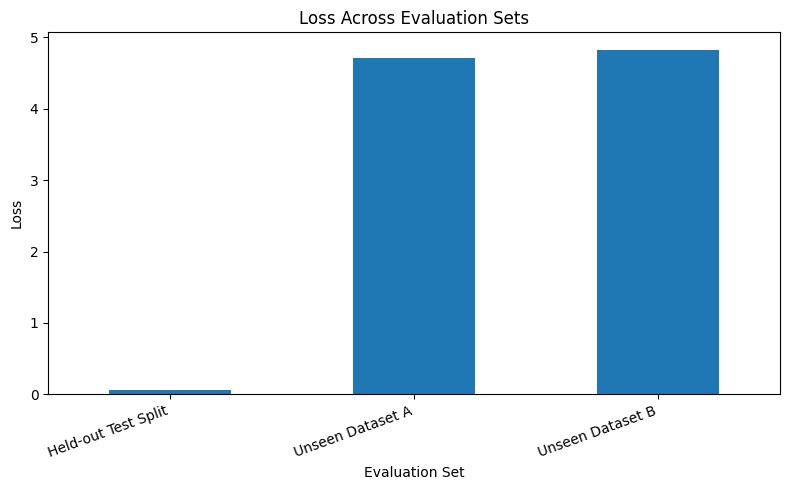

In [7]:
ax = evaluation_df.set_index('Evaluation Set')['Loss'].plot(kind='bar', figsize=(8, 5))
plt.ylabel('Loss')
plt.title('Loss Across Evaluation Sets')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Optional: loading saved result files

The notebook currently uses embedded results so it works in GitHub even if a grader does not have your local files. If you export CSVs into `results/`, use the pattern below to load them.

In [8]:
def load_results_csv(filename, fallback_df):
    path = RESULTS_DIR / filename
    if path.exists():
        print(f'Loaded {path}')
        return pd.read_csv(path)
    print(f'{path} not found; using embedded results.')
    return fallback_df.copy()

# Example:
# evaluation_df = load_results_csv('MODEL_final_evaluation.csv', evaluation_df)

## Final interpretation

The final selected ResNet-50 run was **R13**, which used AdamW, learning rate `1e-4`, weight decay `1e-3`, light augmentation, batch size `8`, and `ReduceLROnPlateau`. R13 improved the best validation F1 from the earlier R08 configuration to approximately **0.9790**. On the held-out in-domain test split, ResNet-50 achieved strong performance with test F1 of approximately **0.9786** and ROC-AUC of approximately **0.9980**.

The performance drop on both unseen datasets shows that the model generalized much less reliably to external datasets than to the original held-out split. This suggests dataset shift: the model learned patterns that worked well on the original data distribution but did not transfer cleanly to new sources.

## Files to include in GitHub

- Final notebook: this notebook
- Experiment notebook: `resNet-50_exp-REDO-Copy1.ipynb`
- Reproducibility notebook: `ResNet50_reproduce_updated.ipynb`
- Dataset link or instructions in `README.md`
- Checkpoint link or instructions in `checkpoints/README.md` if the `.pth` file is too large for GitHub